In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount = True)
%cd '/content/drive/MyDrive/SportDataChallenge26/2000-2020 SDC'

Mounted at /content/drive
/content/drive/MyDrive/SportDataChallenge26/2000-2020 SDC


In [2]:
import pandas as pd
import numpy as np
import torch

In [3]:
# Exploring dataset
df = pd.read_csv('nfl_combine_2000_2020.csv')
df = df.dropna(subset=['wAVOE'])
df.columns

Index(['Rnd', 'Pick', 'Tm', 'Player', 'Pos', 'Age', 'To', 'AP1', 'PB', 'St',
       'wAV', 'DrAV', 'G', 'Cmp', 'Pass_Att', 'Pass_Yds', 'Pass_TD',
       'Pass_Int', 'Rush_Att', 'Rush_Yds', 'Rush_TD', 'Rec', 'Rec_Yds',
       'Rec_TD', 'Solo', 'Def_Int', 'Sk', 'College/Univ', 'Misc', 'pfref_id',
       'Season', 'wAVOE', 'PosGroup', '40yd', 'Vertical', 'Broad Jump', 'Cone',
       'Shuttle', 'Wt', 'BroadJump'],
      dtype='object')

In [4]:
# FEATURES AND TARGETS

# Within-position z-scores for combine metrics
# This is what the GNN is SUPPOSED to learn, but having it as an explicit
# feature helps all three models and strengthens the engineered baseline
for metric in ['40yd', 'Vertical', 'Broad Jump', 'Cone', 'Shuttle', 'Wt']:
    if metric in df.columns:
        grp = df.groupby('Pos')[metric]
        df[f'{metric}_pos_z'] = (df[metric] - grp.transform('mean')) / (grp.transform('std') + 1e-8)

# Create missing flags for combine metrics
for metric in ['40yd', 'Vertical', 'Broad Jump', 'Cone', 'Shuttle']:
    df[f'{metric}_missing'] = df[metric].isna().astype(int)

# Create log_pick
df['log_pick'] = np.log(df['Pick'])

# Position encoding — same as before
df['Pos_idx'], pos_map = pd.factorize(df['Pos'])
df['pos_enc'] = df['Pos_idx']
pos_idx = df['Pos_idx'].values
num_positions = len(pos_map)

# ── PRIORITY 1 FIX: expanded feature set including combine metrics ────────────
# Original only used ['Rnd', 'Pick', 'Age'] — the gate had nothing
# position-specific to condition on. Now we feed it the combine measurements
# that actually vary by position (40yd matters for WR, Wt matters for OL, etc.)
# feature_cols = ['Rnd', 'Pick', 'Age', '40yd', 'Vertical', 'Broad Jump', 'Cone', 'Shuttle', 'Wt']
COMBINE_FEATS = ['40yd', 'Vertical', 'Broad Jump', 'Cone', 'Shuttle', 'Wt']
COMBINE_Z     = [f'{m}_pos_z' for m in COMBINE_FEATS]
MISSING_FLAGS = [f'{m}_missing' for m in ['40yd', 'Vertical', 'Broad Jump', 'Cone', 'Shuttle']]
DRAFT_FEATS   = ['Rnd', 'Pick', 'log_pick', 'Age']

ALL_FEATS = COMBINE_FEATS + COMBINE_Z + MISSING_FLAGS + DRAFT_FEATS + ['pos_enc']
# Median impute missing combine values (players who skipped events)
# Use median rather than 0 — filling with 0 would make a 0-lb player, etc.
X_raw = df[ALL_FEATS].copy()
X_raw = X_raw.fillna(X_raw.median())
X = X_raw.values

# Lookup table for reference
mapping_df = pd.DataFrame({
    'Code': range(len(pos_map)),
    'Position': pos_map
})
print(mapping_df)

# Regression target — continuous wAVOE
y_reg = df['wAVOE'].values

# Classification target (top 30% = hit)
threshold = df['wAVOE'].quantile(0.7)
df['y_cls'] = (df['wAVOE'] > threshold).astype(int)
y_cls = df['y_cls'].values

# Z-score scale — same formula as before, now across 9 features
X_scaled = (X - X.mean(axis=0)) / (X.std(axis=0) + 1e-8)
X = torch.tensor(X_scaled, dtype=torch.float32)
pos_idx = torch.tensor(pos_idx, dtype=torch.long)

print(f"Feature matrix shape: {X.shape}  (should be N x 9)")
print(f"Num positions: {num_positions}")

    Code Position
0      0       DE
1      1       LB
2      2        T
3      3       WR
4      4       RB
5      5       DT
6      6       TE
7      7       DB
8      8        K
9      9       QB
10    10        G
11    11        C
12    12       FB
13    13        P
14    14       NT
15    15       DL
16    16       OL
17    17      OLB
18    18       CB
19    19        S
20    20      ILB
21    21       LS
Feature matrix shape: torch.Size([4836, 22])  (should be N x 9)
Num positions: 22


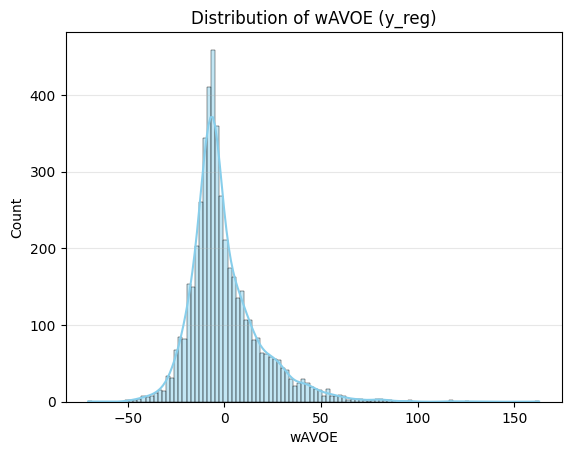

In [5]:
# Distribution of wAVOE
import matplotlib.pyplot as plt
import seaborn as sns
sns.histplot(df['wAVOE'].dropna(), kde=True, color='skyblue')
plt.title('Distribution of wAVOE (y_reg)')
plt.grid(axis='y', alpha=0.3)

In [6]:
# FiLM Generator — Feature-wise Linear Modulation
# Unchanged from original — architecture is correct, it just needed better inputs

import torch.nn as nn

class FiLMGenerator(nn.Module):
    """
    Generates position-conditioned scale (gamma) and shift (beta) vectors.
    These gate the evaluation network's hidden activations, allowing the model
    to weigh combine metrics differently per position.
    """
    def __init__(self, num_positions, emb_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(num_positions, emb_dim)
        self.mlp = nn.Sequential(
            nn.Linear(emb_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 2 * hidden_dim)  # outputs gamma + beta
        )

    def forward(self, pos_idx):
        emb = self.embedding(pos_idx)
        gamma_beta = self.mlp(emb)
        gamma, beta = gamma_beta.chunk(2, dim=-1)
        gamma = gamma.clamp(-5, 5)
        beta = beta.clamp(-5, 5)
        return gamma, beta

In [7]:
# Gated Model (FiLM applied)
# input_dim is now 9 instead of 3 — no other architecture changes needed

class GatedModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_positions):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.film = FiLMGenerator(num_positions, 20, hidden_dim)
        self.reg_head = nn.Linear(hidden_dim, 1)
        self.cls_head = nn.Linear(hidden_dim, 1)

    def forward(self, x, pos_idx):
        gamma, beta = self.film(pos_idx)
        h = self.fc1(x)
        h = gamma * h + beta  # position gate conditions the combine metrics
        h = torch.relu(h)
        h = self.fc2(h)
        h = gamma * h + beta
        h = torch.relu(h)
        reg_out = self.reg_head(h)
        cls_logits = self.cls_head(h)
        return reg_out, cls_logits

In [8]:
# Loss functions (with class imbalance handling) — unchanged
pos_weight = (y_cls == 0).sum() / (y_cls == 1).sum()
pos_weight = torch.tensor(pos_weight)

loss_fn_reg = nn.MSELoss()
loss_fn_cls = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

def compute_loss(reg_pred, reg_true, cls_logits, cls_true):
    return (
        loss_fn_reg(reg_pred, reg_true) +
        loss_fn_cls(cls_logits, cls_true)
    )

In [9]:
# Train / Validation split — unchanged
from sklearn.model_selection import train_test_split

X_train, X_val, pos_train, pos_val, yreg_train, yreg_val, ycls_train, ycls_val = train_test_split(
    X, pos_idx, y_reg, y_cls, test_size=0.2, random_state=42
)

yreg_train = torch.tensor(yreg_train, dtype=torch.float32).view(-1, 1)
yreg_val   = torch.tensor(yreg_val,   dtype=torch.float32).view(-1, 1)
ycls_train = torch.tensor(ycls_train, dtype=torch.float32).view(-1, 1)
ycls_val   = torch.tensor(ycls_val,   dtype=torch.float32).view(-1, 1)

def compute_mae(pred, true):
    return torch.mean(torch.abs(pred - true))

In [10]:
# Initialize model
model = GatedModel(input_dim=X.shape[1], hidden_dim=64, num_positions=num_positions)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
print(f"GatedModel input_dim: {X.shape[1]}")

GatedModel input_dim: 22


In [11]:
# Train GatedModel — unchanged from original
best_val_mae = float('inf')

for epoch in range(100):
    model.train()
    reg_pred, cls_logits = model(X_train, pos_train)
    loss = compute_loss(reg_pred, yreg_train, cls_logits, ycls_train)
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

    model.eval()
    with torch.no_grad():
        reg_val_pred, cls_val_logits = model(X_val, pos_val)
        val_mae = compute_mae(reg_val_pred, yreg_val)

    if val_mae < best_val_mae:
        best_val_mae = val_mae
        torch.save(model.state_dict(), 'best_model.pt')

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Val MAE: {val_mae:.4f}")

print(f"\nBest val MAE: {best_val_mae:.4f}")
print("Saved best_model.pt")

Epoch 0, Val MAE: 13.5276
Epoch 10, Val MAE: 13.4863
Epoch 20, Val MAE: 13.4427
Epoch 30, Val MAE: 13.3748
Epoch 40, Val MAE: 13.2429
Epoch 50, Val MAE: 13.1099
Epoch 60, Val MAE: 13.0435
Epoch 70, Val MAE: 13.0123
Epoch 80, Val MAE: 12.9703
Epoch 90, Val MAE: 12.9301

Best val MAE: 12.9063
Saved best_model.pt


In [12]:
# Baseline MLP — unchanged
class MLPBaseline(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.reg_head = nn.Linear(hidden_dim, 1)
        self.cls_head = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        h = torch.relu(self.fc1(x))
        h = torch.relu(self.fc2(h))
        return self.reg_head(h), self.cls_head(h)

In [13]:
# Train Baseline MLP — unchanged
baseline = MLPBaseline(input_dim=X.shape[1], hidden_dim=64)
optimizer_base = torch.optim.Adam(baseline.parameters(), lr=1e-3)
best_val_mae_base = float('inf')

for epoch in range(100):
    baseline.train()
    reg_pred, cls_logits = baseline(X_train)
    loss = compute_loss(reg_pred, yreg_train, cls_logits, ycls_train)
    optimizer_base.zero_grad()
    loss.backward()
    optimizer_base.step()

    baseline.eval()
    with torch.no_grad():
        reg_val_pred, cls_val_logits = baseline(X_val)
        val_mae = compute_mae(reg_val_pred, yreg_val)

    if val_mae < best_val_mae_base:
        best_val_mae_base = val_mae
        torch.save(baseline.state_dict(), 'best_baseline.pt')

    if epoch % 10 == 0:
        print(f"[Baseline] Epoch {epoch}, Val MAE: {val_mae:.4f}")

[Baseline] Epoch 0, Val MAE: 13.5067
[Baseline] Epoch 10, Val MAE: 13.4909
[Baseline] Epoch 20, Val MAE: 13.4567
[Baseline] Epoch 30, Val MAE: 13.3944
[Baseline] Epoch 40, Val MAE: 13.3148
[Baseline] Epoch 50, Val MAE: 13.2353
[Baseline] Epoch 60, Val MAE: 13.1614
[Baseline] Epoch 70, Val MAE: 13.1122
[Baseline] Epoch 80, Val MAE: 13.1043
[Baseline] Epoch 90, Val MAE: 13.0913


In [14]:
# Load best checkpoints and evaluate — unchanged
model.load_state_dict(torch.load('best_model.pt'))
model.eval()
with torch.no_grad():
    reg_pred, cls_logits = model(X_val, pos_val)

mae_gated = compute_mae(reg_pred, yreg_val)
probs = torch.sigmoid(cls_logits)
brier_gated = torch.mean((probs - ycls_val) ** 2)

baseline.load_state_dict(torch.load('best_baseline.pt'))
baseline.eval()
with torch.no_grad():
    reg_pred_base, cls_logits_base = baseline(X_val)

mae_base = compute_mae(reg_pred_base, yreg_val)
probs_base = torch.sigmoid(cls_logits_base)
brier_base = torch.mean((probs_base - ycls_val) ** 2)

In [15]:
# PR-AUC — unchanged
from sklearn.metrics import average_precision_score

pr_auc_gated = average_precision_score(
    ycls_val.detach().cpu().numpy(),
    probs.detach().cpu().numpy()
)
pr_auc_base = average_precision_score(
    ycls_val.detach().cpu().numpy(),
    probs_base.detach().cpu().numpy()
)

In [16]:
# Final comparison
print('=== FINAL RESULTS ===')
print('\nGATED MODEL')
print('MAE:   ', mae_gated.item())
print('Brier: ', brier_gated.item())
print('PR-AUC:', pr_auc_gated)

print('\nBASELINE MLP')
print('MAE:   ', mae_base.item())
print('Brier: ', brier_base.item())
print('PR-AUC:', pr_auc_base)

=== FINAL RESULTS ===

GATED MODEL
MAE:    12.906340599060059
Brier:  0.23617149889469147
PR-AUC: 0.4198728593561105

BASELINE MLP
MAE:    13.086730003356934
Brier:  0.23606665432453156
PR-AUC: 0.42289359558568357


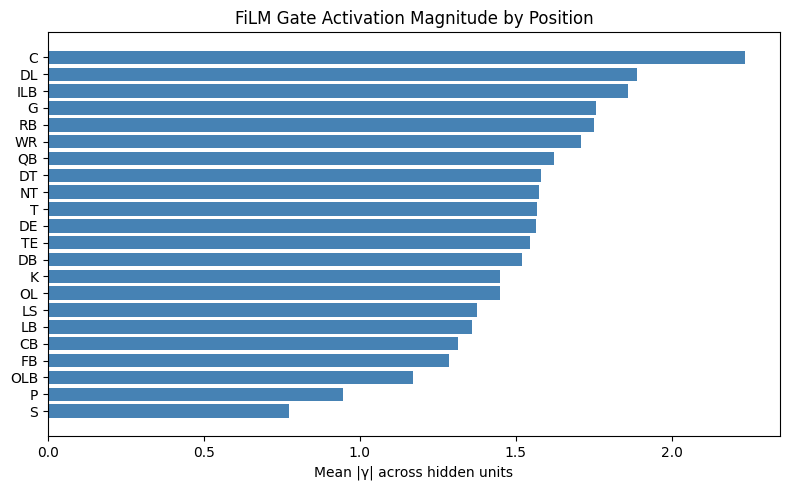

Saved figures/gate_magnitude.png


In [17]:
# ── PRIORITY 3: Gate weight visualization ────────────────────────────────────
# Extracts the average gamma (scale) magnitude that the FiLM gate assigns
# to each position. A high magnitude means the gate is making large adjustments
# for that position — i.e. combine metrics matter more for those positions.

model.eval()
pos_labels = list(pos_map)

gate_gammas = []
with torch.no_grad():
    for i in range(num_positions):
        pid = torch.tensor([i], dtype=torch.long)
        gamma, _ = model.film(pid)
        gate_gammas.append(gamma.squeeze().numpy())

gate_df = pd.DataFrame(gate_gammas, index=pos_labels,
                       columns=[f'h{i}' for i in range(64)])

# Average |gamma| per position — how strongly does each position shift the gate
gate_magnitude = gate_df.abs().mean(axis=1).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(gate_magnitude.index, gate_magnitude.values, color='steelblue')
ax.set_xlabel('Mean |γ| across hidden units')
ax.set_title('FiLM Gate Activation Magnitude by Position')
ax.invert_yaxis()
fig.tight_layout()
fig.savefig('figures/gate_magnitude.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved figures/gate_magnitude.png")

In [18]:
# Generate predictions over the full dataset for B's visualizations
# model, X, pos_idx, df are all already defined from training above

model.eval()
with torch.no_grad():
    reg_full, cls_full = model(X, pos_idx)

df['gnn_wavoe_pred'] = reg_full.squeeze().numpy()
df['gnn_hit_prob']   = torch.sigmoid(cls_full).squeeze().numpy()

print(f"Predictions attached — {len(df)} players")
print(df[['Player', 'Pos', 'Pick', 'wAVOE', 'gnn_wavoe_pred', 'gnn_hit_prob']].head())

Predictions attached — 4836 players
            Player Pos  Pick      wAVOE  gnn_wavoe_pred  gnn_hit_prob
0   Courtney Brown  DE     1 -49.428571       -9.441483      0.557912
1  LaVar Arrington  LB     2  -7.476190        1.182513      0.716366
2    Chris Samuels   T     3  10.714286       -2.500758      0.702273
3    Peter Warrick  WR     4 -26.904762      -17.429026      0.595348
4      Jamal Lewis  RB     5  13.523810        3.339362      0.728359


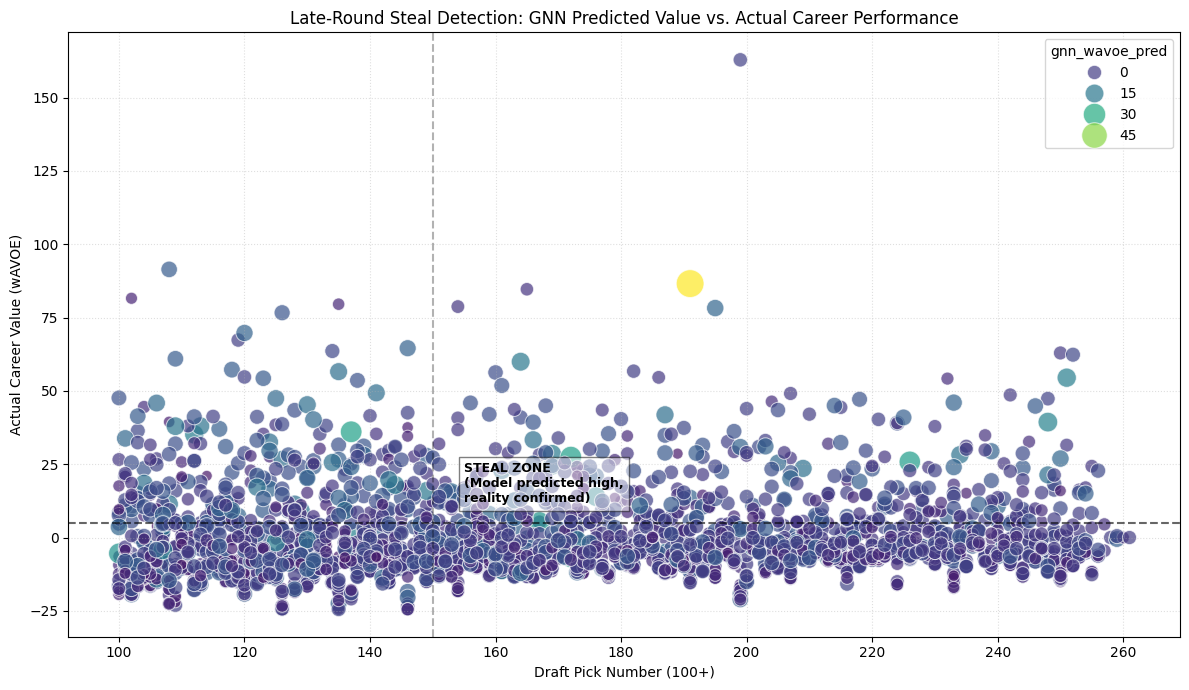

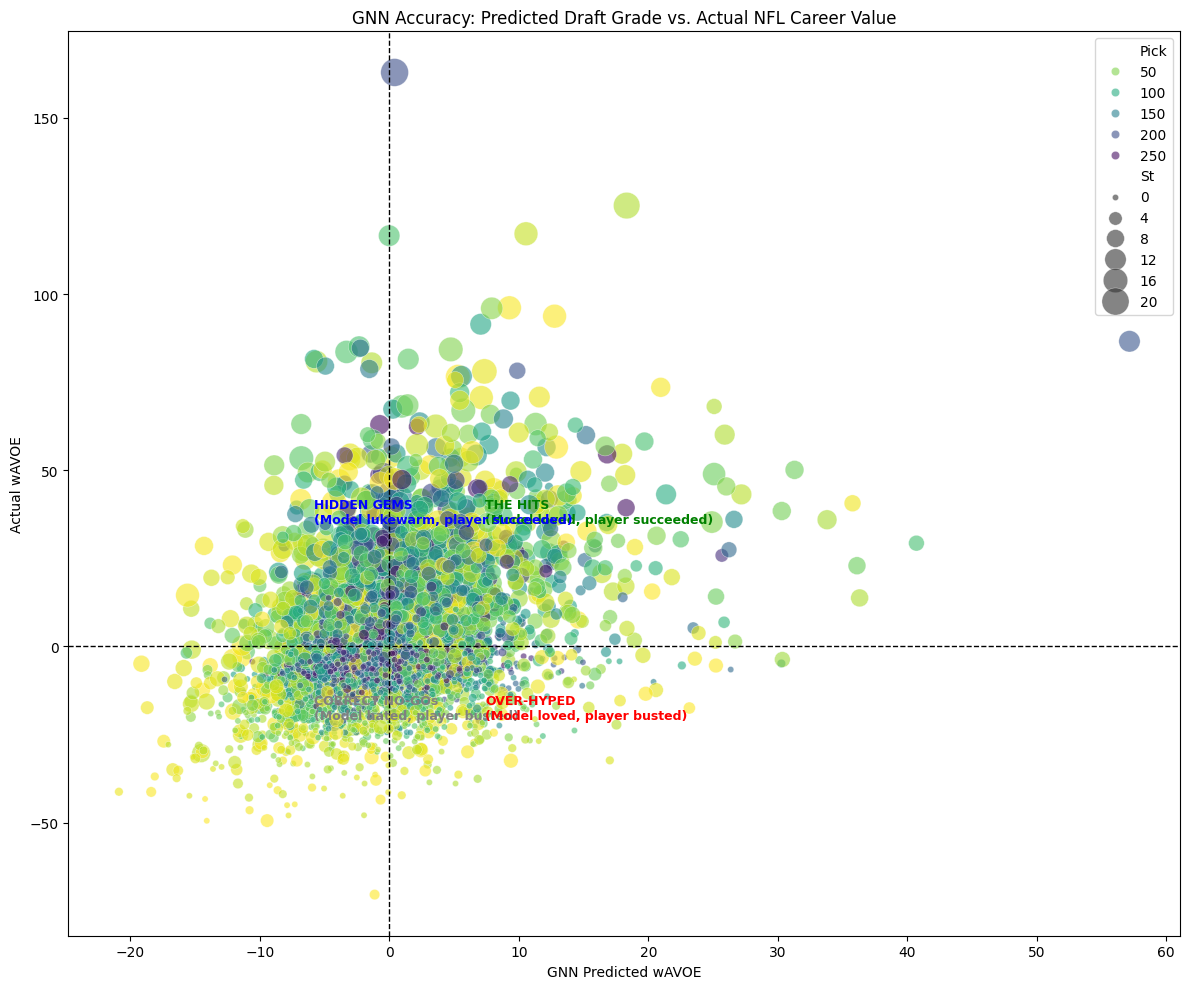

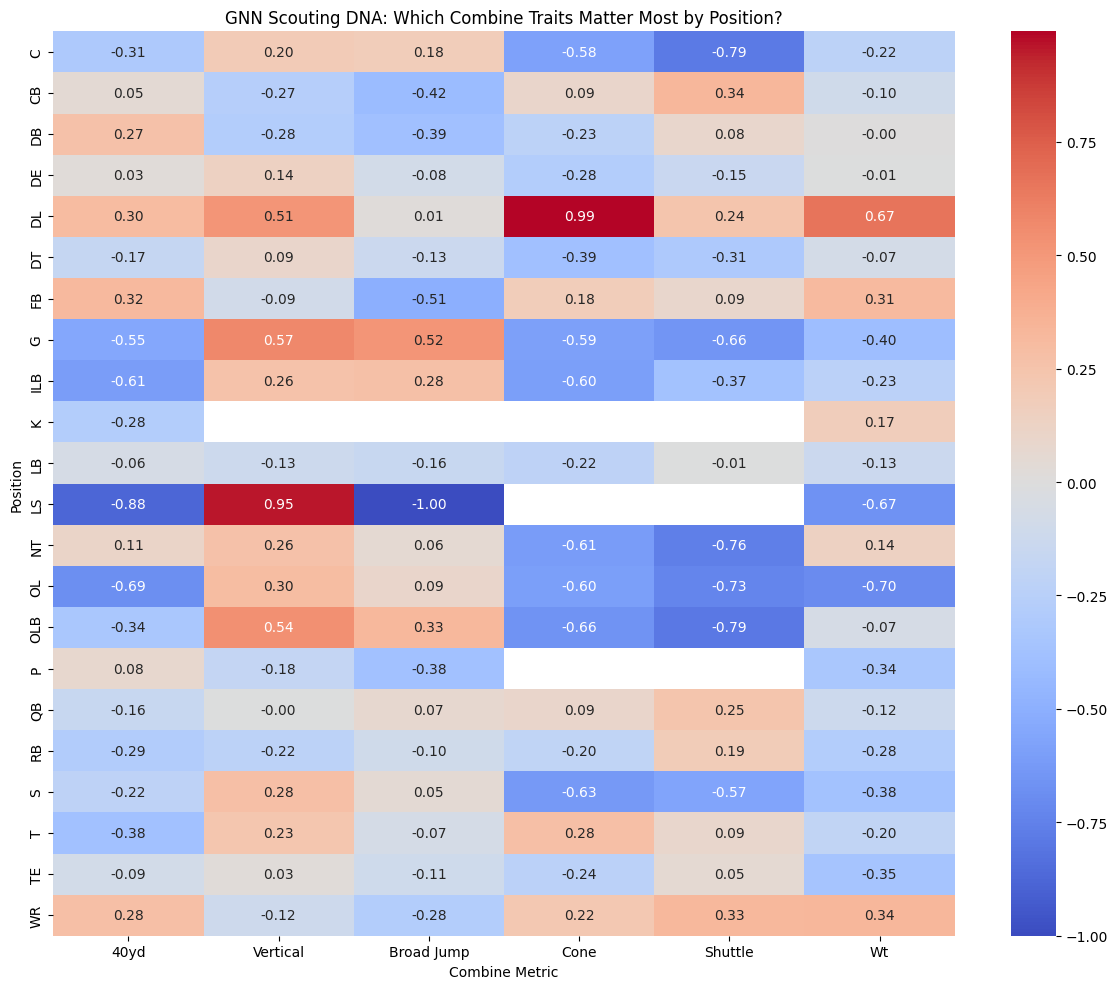

Top 20 GNN-predicted late-round steals:
            Player Pos  Pick  Season   wAVOE  gnn_wavoe_pred  gnn_hit_prob
       Jason Kelce   C   191    2011  86.579       57.157001         0.923
      Duke Preston   C   122    2005  -4.842       30.271000         0.975
     Grady Jarrett  NT   137    2015  36.053       26.611000         0.910
       Scott Young   G   172    2005  -6.562       26.361000         0.837
     Brandon Fusco   C   172    2011  27.438       26.226000         0.816
      A.Q. Shipley   C   226    2009  25.824       25.672001         0.751
       Nick Leckey   C   167    2004   5.235       23.464001         0.911
  Alex Stepanovich   C   100    2004  -5.400       22.587999         0.957
      Drew Hodgdon   C   151    2005 -10.056       20.400999         0.806
       Kyle Kosier   G   248    2002  39.357       18.280001         0.598
David Quessenberry  OL   176    2013  13.947       18.018000         0.857
  Kendell Beckwith ILB   107    2017  -4.238       17.773001

In [19]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import os
os.makedirs('figures', exist_ok=True)

# 1. Late-round steal detection scatter
late_rounds = df[df['Pick'] >= 100].copy()

plt.figure(figsize=(12, 7))
sns.scatterplot(data=late_rounds, x='Pick', y='wAVOE',
                hue='gnn_wavoe_pred', palette='viridis',
                size='gnn_wavoe_pred', sizes=(40, 400), alpha=0.7)
plt.axhline(5, color='black', linestyle='--', alpha=0.6)
plt.axvline(150, color='black', linestyle='--', alpha=0.3)
plt.text(155, 12, "STEAL ZONE\n(Model predicted high,\nreality confirmed)",
         bbox=dict(facecolor='white', alpha=0.5), fontweight='bold', fontsize=9)
plt.title("Late-Round Steal Detection: GNN Predicted Value vs. Actual Career Performance")
plt.xlabel("Draft Pick Number (100+)")
plt.ylabel("Actual Career Value (wAVOE)")
plt.grid(True, linestyle=':', alpha=0.4)
plt.tight_layout()
plt.savefig('figures/steal_detection_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. GNN predicted vs actual — quadrant plot
fig, ax = plt.subplots(figsize=(12, 10))
sns.scatterplot(data=df, x='gnn_wavoe_pred', y='wAVOE',
                hue='Pick', size='St', sizes=(20, 400),
                palette='viridis_r', alpha=0.6, ax=ax)

ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.axvline(0, color='black', linestyle='--', linewidth=1)

xmax = df['gnn_wavoe_pred'].quantile(0.97)
xmin = df['gnn_wavoe_pred'].quantile(0.03)
ymax = df['wAVOE'].quantile(0.97)
ymin = df['wAVOE'].quantile(0.03)

ax.text(xmax * 0.6, ymax * 0.8, "THE HITS\n(Model loved, player succeeded)",
        fontsize=9, weight='bold', color='green')
ax.text(xmin * 0.6, ymax * 0.8, "HIDDEN GEMS\n(Model lukewarm, player succeeded)",
        fontsize=9, weight='bold', color='blue')
ax.text(xmin * 0.6, ymin * 0.8, "CORRECT NO-GOs\n(Model hated, player busted)",
        fontsize=9, weight='bold', color='gray')
ax.text(xmax * 0.6, ymin * 0.8, "OVER-HYPED\n(Model loved, player busted)",
        fontsize=9, weight='bold', color='red')

ax.set_title("GNN Accuracy: Predicted Draft Grade vs. Actual NFL Career Value")
ax.set_xlabel("GNN Predicted wAVOE")
ax.set_ylabel("Actual wAVOE")
plt.tight_layout()
plt.savefig('figures/gnn_quadrant_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. Combine trait correlation with GNN predictions by position group
traits = ['40yd', 'Vertical', 'Broad Jump', 'Cone', 'Shuttle', 'Wt']

trait_corr = (
    df.groupby('Pos')[traits + ['gnn_wavoe_pred']]
    .corr()['gnn_wavoe_pred']
    .unstack()
    .drop(columns='gnn_wavoe_pred', errors='ignore')
)

plt.figure(figsize=(12, 10))
sns.heatmap(trait_corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title("GNN Scouting DNA: Which Combine Traits Matter Most by Position?")
plt.xlabel("Combine Metric")
plt.ylabel("Position")
plt.tight_layout()
plt.savefig('figures/gnn_trait_corr_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# 4. Top 20 steals table
steals = (
    df[df['Pick'] >= 100]
    .sort_values('gnn_wavoe_pred', ascending=False)
    .head(20)[['Player', 'Pos', 'Pick', 'Season', 'wAVOE', 'gnn_wavoe_pred', 'gnn_hit_prob']]
    .round(3)
)
print("Top 20 GNN-predicted late-round steals:")
print(steals.to_string(index=False))